This notebook processes the outputs of brute_force_mixing.py for experiment names
* "full_aug" and "partial_aug" for jan 21 meeting
* expected_coef_all_groups_full_aug, expected_coef_all_groups_partial_aug, expected_coef_filter_groups_full_aug, expected_coef_filter_groups_partial_aug
    * Note, this experiment requires ~13 min per base group

In contrast to the partial base group notebook, the base group is not sampled for these experiments and the augmentation group is not necessarily the same size as the base group.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)
import pickle

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from regressor import ExpPerceptronRegressor, PolynomialRegressor

In [6]:
SMALL_SIZE = 18
MEDIUM_SIZE = 24
BIGGER_SIZE = 24
plt.rc('font', size=SMALL_SIZE, family = "Nimbus Roman")          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
# plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [7]:
# Load mixing ratios and metrics
exp_name = "expected_coef_all_groups_partial_aug_test_all"
filename = f"../results/mixing_results_by_group_{exp_name}.pickle"
with open(filename, "rb") as pickleFile:
    mixing_results_by_group = pickle.load(pickleFile)

for label in mixing_results_by_group:
    assert len(mixing_results_by_group[label]["validation ps"]) == len(mixing_results_by_group[label]["validation metrics"])
    print(f"{label}: {len(mixing_results_by_group[label]['validation ps'])} trials")
    
    ps = mixing_results_by_group[label]["validation ps"]
    group_labels = set(ps[0].keys())
    assert np.all([group_labels == set(p.keys()) for p in ps])
    
    metric_dicts = mixing_results_by_group[label]["validation metrics"]
    metric_names = set(metric_dicts[0].keys())
    assert np.all([metric_names == set(metric_dict.keys()) for metric_dict in metric_dicts])

1: 500 trials
18: 500 trials
25: 500 trials
35: 500 trials
45: 500 trials
50: 500 trials
56: 500 trials


## Analyzing Best Mixing Ratios

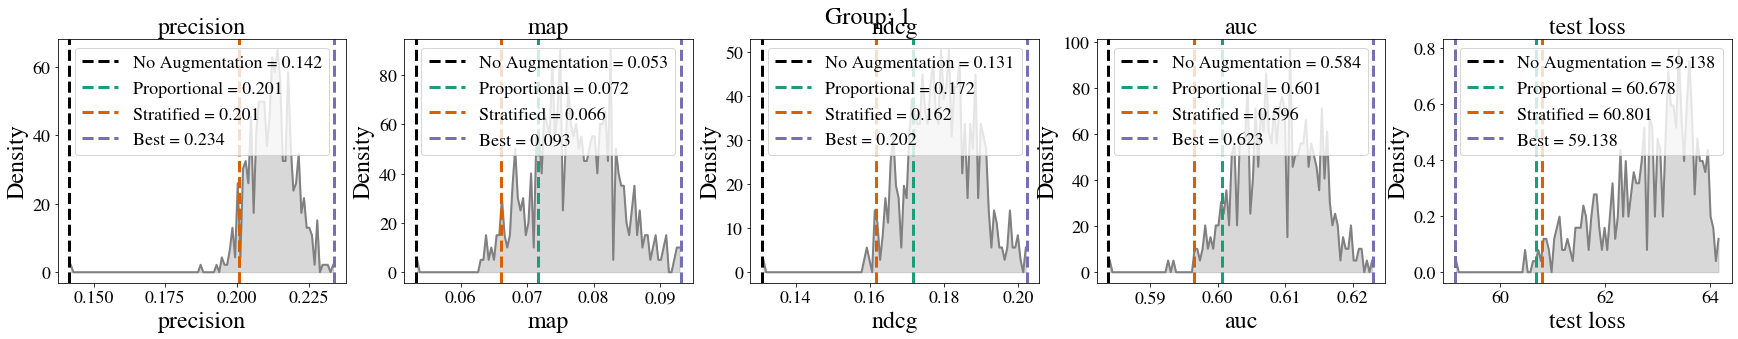

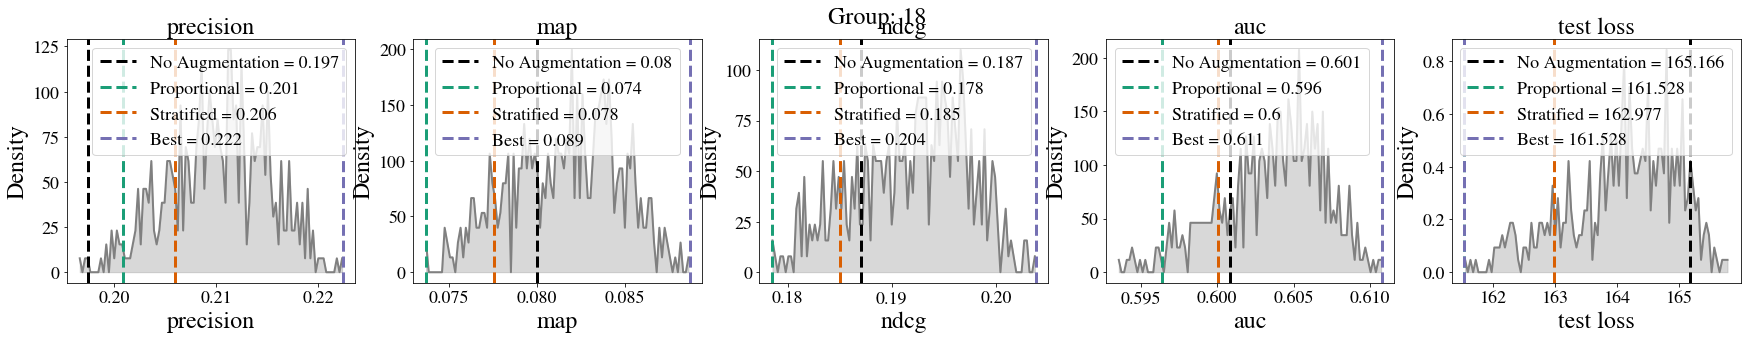

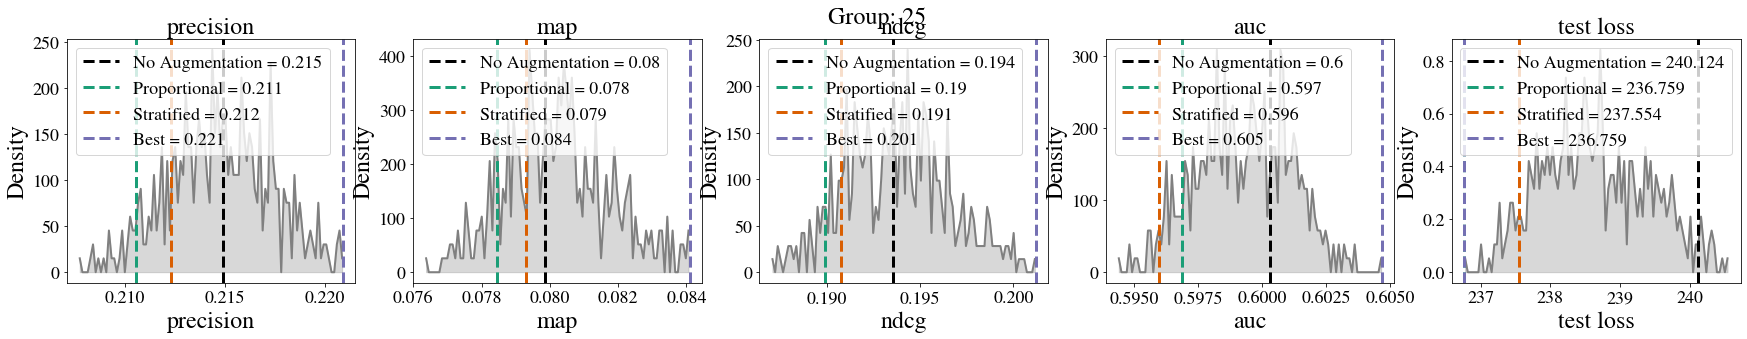

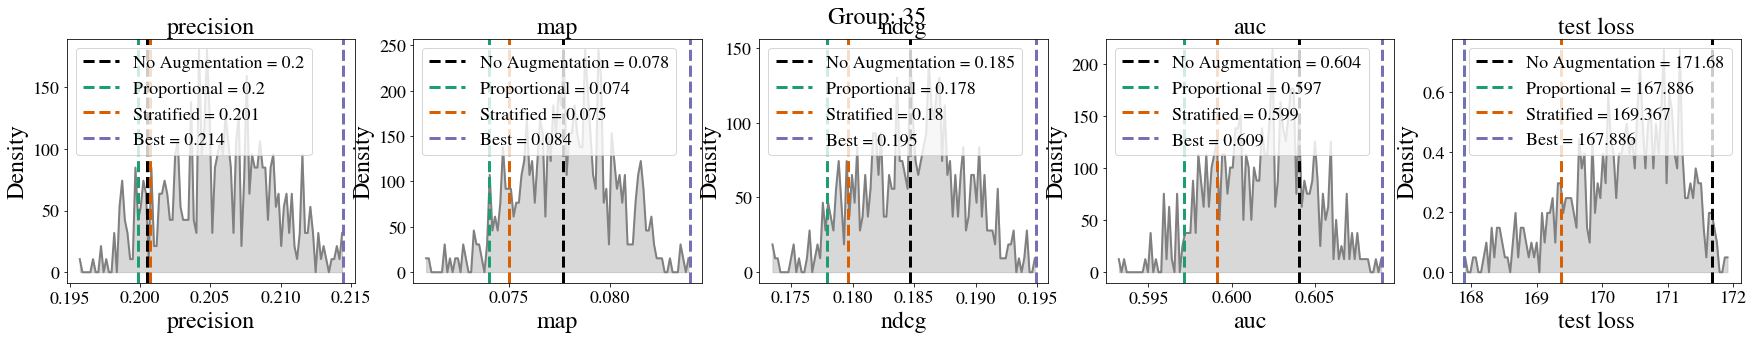

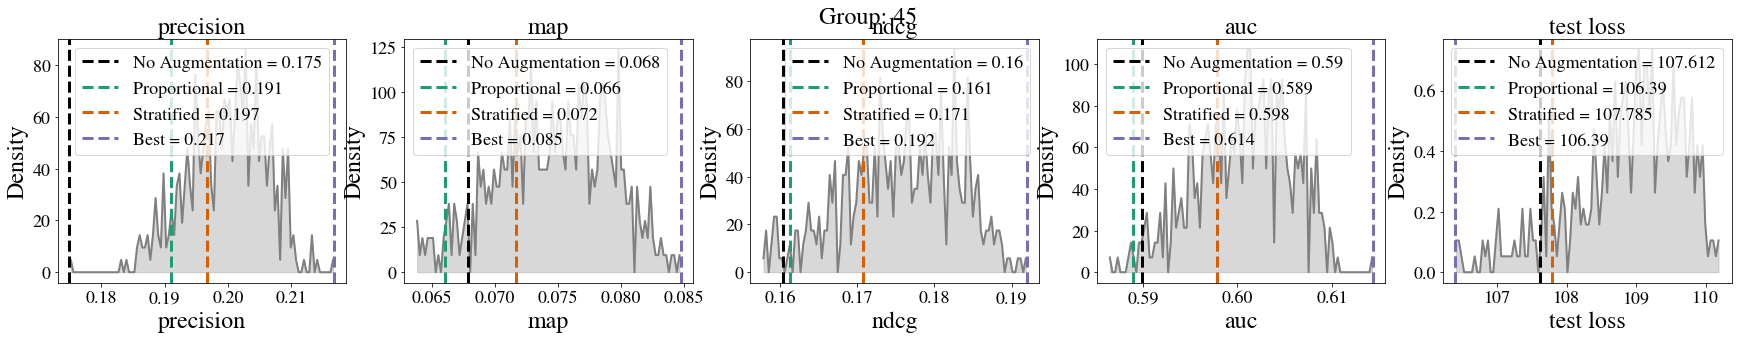

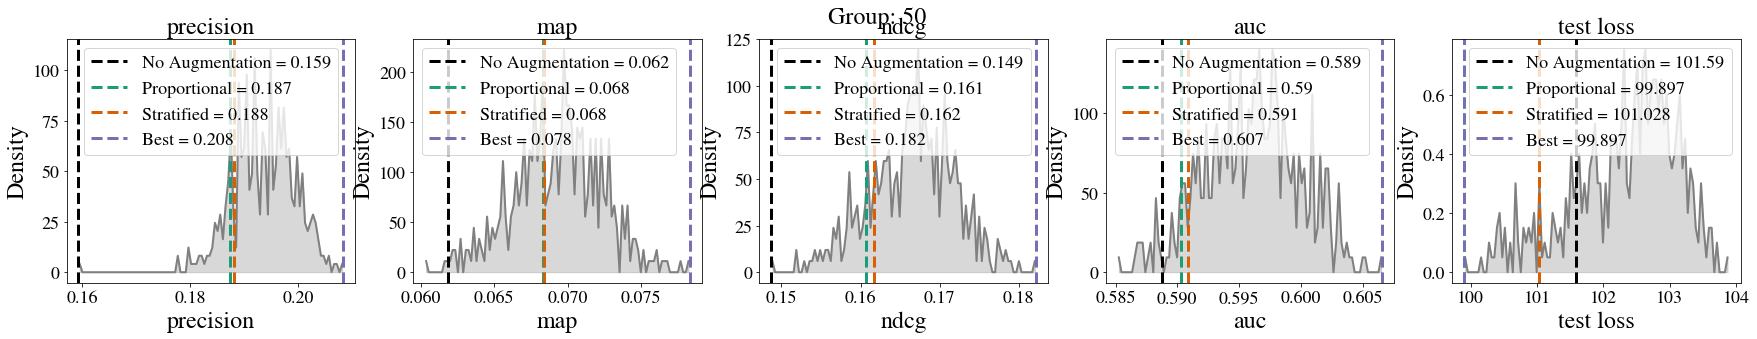

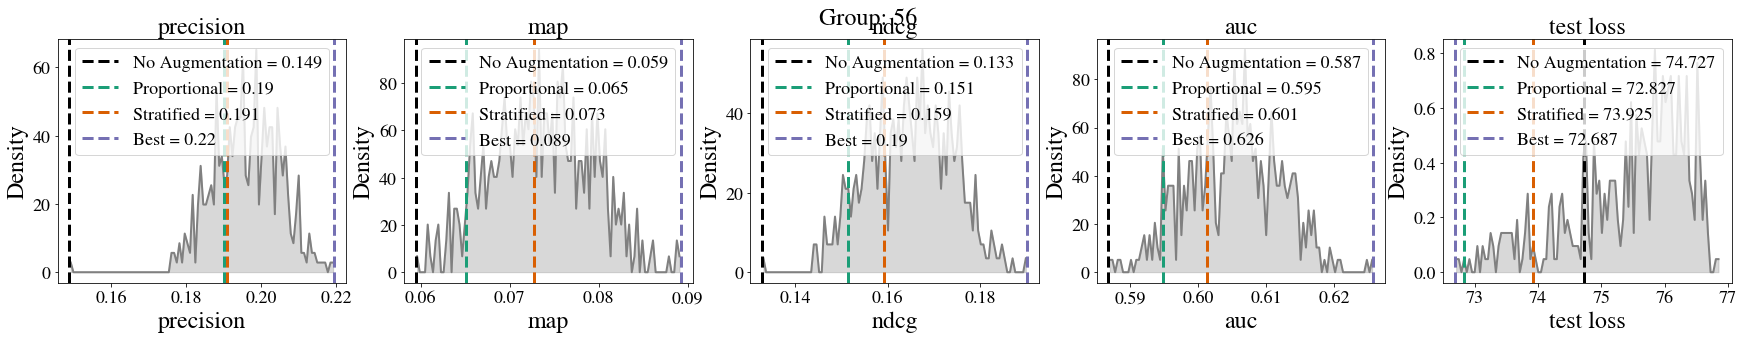

In [8]:
colors = ["black", "#1b9e77", "#d95f02", "#7570b3"]
def plot_density_with_baseline(values, baseline_tuples, value_name="Values", title="Density Plot", ax=None):
    """
    Pure Matplotlib density plot with a vertical dashed baseline line.
    """
    values = np.asarray(values)

    # Compute histogram-based density estimate
    density, bins = np.histogram(values, bins=100, density=True)
    centers = 0.5 * (bins[:-1] + bins[1:])

    if ax == None:
        fig, ax = plt.subplots()

    ax.plot(centers, density, linewidth=2, color="gray")
    ax.fill_between(centers, density, alpha=0.3, color="gray")

    for baseline_idx, (baseline_name, baseline_val) in enumerate(baseline_tuples):
        ax.axvline(baseline_val, 
                   color=colors[baseline_idx],
                   linestyle="--", linewidth=3, 
                   label=f"{baseline_name} = {round(baseline_val, 3)}")

    ax.set_title(title)
    ax.set_xlabel(value_name)
    ax.set_ylabel("Density")
    ax.legend()

for label in mixing_results_by_group:
    metric_names = list(mixing_results_by_group[label]["validation metrics"][0].keys())
    metric_dicts = mixing_results_by_group[label]["validation metrics"]
    
    fig, axs = plt.subplots(ncols=len(metric_names), figsize=(6*len(metric_names), 4.5))
    fig.suptitle(f"Group: {label}")
    for metric_idx, metric_name in enumerate(metric_names):
        metric_vals = [metric_dict[metric_name] for metric_dict in metric_dicts]
        plot_density_with_baseline(metric_vals,
                                  baseline_tuples=[
                                      ("No Augmentation", metric_vals[0]), 
                                      ("Proportional", metric_vals[1]),
                                      ("Stratified", metric_vals[2]),
                                      ("Best", np.min(metric_vals) if "loss" in metric_name else np.max(metric_vals))
                                  ],
                                  value_name=metric_name,
                                  title=metric_name,
                                  ax=axs[metric_idx])


In [9]:
## merge in the test metrics for the best full augmentation
exp_name = "expected_coef_all_groups_full_aug"
filename = f"../results/mixing_results_by_group_{exp_name}.pickle"
metric_name = "precision"

with open(filename, "rb") as pickleFile:
    mixing_results_by_group_full_aug = pickle.load(pickleFile)

group_labels = list(mixing_results_by_group.keys())
optimal_ps = []
for label in group_labels:
    
    ######### BEST PARTIAL ######### 
    optimal_validation_idx_partial = np.argmax([
        metric_dict[metric_name] 
        for metric_dict in mixing_results_by_group[label]["validation metrics"]
    ])
    
#     optimal_p = mixing_results_by_group[label]['validation ps'][optimal_validation_idx_partial]
#     optimal_ps.append(
#         [optimal_p[label] for label in optimal_p]
#     )
    
    ## TEMPORARY TO ACCOMODATE DUPLICATE ENTRIES IN TEST_PS
    optimal_validation_idx_partial += 3
    
    mixing_results_by_group[label]["test metrics"].append(
        mixing_results_by_group[label]["test metrics"][optimal_validation_idx_partial]
    )

    ######### BEST FULL ######### 
    optimal_validation_idx_full = np.argmax([
        metric_dict[metric_name] 
        for metric_dict in mixing_results_by_group_full_aug[label]["validation metrics"]
    ])
    
    optimal_p = mixing_results_by_group_full_aug[label]['validation ps'][optimal_validation_idx_full]
    optimal_ps.append(
        [optimal_p[label] for label in optimal_p]
    )
    
    ## TEMPORARY TO ACCOMODATE DUPLICATE ENTRIES IN TEST_PS
    optimal_validation_idx_full += 3
    
    mixing_results_by_group[label]["test metrics"].append(
        mixing_results_by_group_full_aug[label]["test metrics"][optimal_validation_idx_full]
    )
    
    # FULL PROPORTIONAL
    mixing_results_by_group[label]["test metrics"].append(
        mixing_results_by_group_full_aug[label]["test metrics"][2]
    )
    
    # FULL STRATIFIED
    mixing_results_by_group[label]["test metrics"].append(
        mixing_results_by_group_full_aug[label]["test metrics"][4]
    )

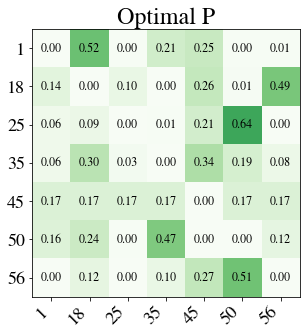

In [10]:
fig, ax = plt.subplots(figsize=(5,5))

# Background
n_rows = len(group_labels)
n_cols = len(group_labels)

optimal_ps = np.array(optimal_ps)

ax.imshow(np.zeros_like(optimal_ps, dtype=float), cmap='gray', vmin=0, vmax=1)

# Fill each cell manually
for i in range(n_rows):
    for j in range(n_cols):

        coef = optimal_ps[i, j]
        color = plt.cm.get_cmap("Greens")(coef)
        
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color))

        # Annotate numeric value
        ax.text(j, i, f"{optimal_ps[i, j]:.2f}", ha="center", va="center", fontsize=12)

# Tick settings
ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_rows))
ax.set_xticklabels(group_labels, rotation=45, ha='right')
ax.set_yticklabels(group_labels)

# Axes limits
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(n_rows - 0.5, -0.5)

ax.set_aspect("equal")
ax.set_title("Optimal P")
plt.tight_layout()
plt.show()

epoch     1/1000 | loss=0.0450872 | ||W||=0.03606
epoch  1000/1000 | loss=3.22998e-05 | ||W||=0.2559
epoch     1/1000 | loss=0.0441979 | ||W||=0.03606
epoch  1000/1000 | loss=1.26408e-05 | ||W||=0.2155
epoch     1/1000 | loss=0.046125 | ||W||=0.03606
epoch  1000/1000 | loss=1.04442e-05 | ||W||=0.2136
epoch     1/1000 | loss=0.0422992 | ||W||=0.03606
epoch  1000/1000 | loss=1.07981e-05 | ||W||=0.206
epoch     1/1000 | loss=0.039945 | ||W||=0.03606
epoch  1000/1000 | loss=1.85835e-05 | ||W||=0.2175
epoch     1/1000 | loss=0.0374919 | ||W||=0.03606
epoch  1000/1000 | loss=1.9387e-05 | ||W||=0.2141
epoch     1/1000 | loss=0.0385872 | ||W||=0.03606
epoch  1000/1000 | loss=2.85971e-05 | ||W||=0.2338


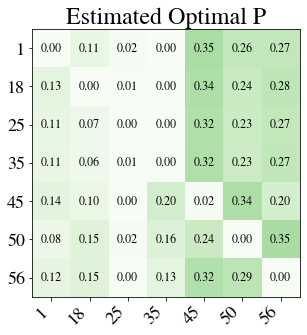

In [7]:
estimated_ps = []
num_training_ratios = 500

for label in group_labels:
    
    y = np.array([
        metric_dict[metric_name] 
        for metric_dict in mixing_results_by_group[label]["validation metrics"]
    ])
    
    P = np.array([
        [p[aug_label] for aug_label in group_labels]
        for p in mixing_results_by_group[label]['validation ps']
    ])
    
    
    rng = np.random.default_rng()
    training_idx = rng.choice(len(y), size=num_training_ratios, replace=False)
    
    model = PolynomialRegressor(dim=len(group_labels), degree=2, seed=0)
    model.fit(P[training_idx], y[training_idx], epochs=1000, verbose_every=1000, loss="mse")
    best_p, best_val = model.find_extrema_on_simplex(steps=200, n_restarts=50, maximize=True)
    
    estimated_ps.append(best_p)

fig, ax = plt.subplots(figsize=(5,5))

# Background
n_rows = len(group_labels)
n_cols = len(group_labels)

estimated_ps = np.array(estimated_ps)

ax.imshow(np.zeros_like(estimated_ps, dtype=float), cmap='gray', vmin=0, vmax=1)

# Fill each cell manually
for i in range(n_rows):
    for j in range(n_cols):

        coef = estimated_ps[i, j]
        color = plt.cm.get_cmap("Greens")(coef)
        
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color))

        # Annotate numeric value
        ax.text(j, i, f"{estimated_ps[i, j]:.2f}", ha="center", va="center", fontsize=12)

# Tick settings
ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_rows))
ax.set_xticklabels(group_labels, rotation=45, ha='right')
ax.set_yticklabels(group_labels)

# Axes limits
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(n_rows - 0.5, -0.5)

ax.set_aspect("equal")
ax.set_title("Estimated Optimal P")
plt.tight_layout()
plt.show()

,Optimal Full Mixing,Proportional,Stratified,Optimal Partial Mixing,Partial Proportional,Partial Stratified
1,72.900158,68.462758,68.938193,58.161648,46.117274,44.215531
18,14.548023,14.618644,14.512712,9.639831,2.048023,3.019068
25,6.852731,6.185152,6.281670,1.801657,-0.329768,0.144776
35,12.126712,10.823296,11.631744,5.477644,1.121927,1.946873
45,28.083751,29.176149,28.629950,18.024579,10.195721,12.926718
50,36.560303,33.910222,35.478637,21.471065,11.736074,16.062737
56,42.539388,39.944393,42.075996,31.603336,15.662651,21.964782


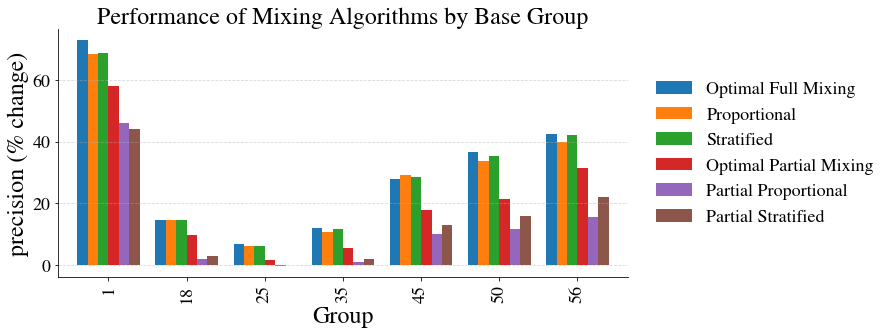

In [18]:
import pandas as pd

def percent_change(old, new):
    return 100 * (new - old) / old

mixing_alg_to_idx = {
    "No Augmentation": 0,
    "Optimal Full Mixing": -3, 
    "Proportional": -2,
    "Stratified": -1,
#     "Best Partial": -2,
#     "Partial Proportional": -1
    "Optimal Partial Mixing": -4, 
    "Partial Proportional": 2,
    "Partial Stratified": 4,
}

dataframe_dict = {}
labels = list(mixing_results_by_group.keys())
for mixing_alg_name, mixing_alg_idx in mixing_alg_to_idx.items():
    if mixing_alg_idx == 0:
        continue
    mixing_alg_values_by_label = [
        percent_change(
            mixing_results_by_group[label]["test metrics"][0][metric_name],
            mixing_results_by_group[label]["test metrics"][mixing_alg_idx][metric_name]
        )
        for label in labels
    ]
    
    dataframe_dict[mixing_alg_name] = mixing_alg_values_by_label

metric_values_df = pd.DataFrame(dataframe_dict, index=labels)


fig, ax = plt.subplots()

metric_values_df.plot(
    ax=ax,
    kind="bar",
    figsize=(15, 5),
    width=0.8,
)

ax.set_xlabel("Group")
ax.set_ylabel(metric_name + " (% change)")
ax.set_title("Performance of Mixing Algorithms by Base Group")

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move legend outside right
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Make room on the right
plt.tight_layout(rect=[0, 0, 0.85, 1])


metric_values_df